In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
import copy
import shutil
import math

print("PyTorch version:", torch.__version__)

# Podešavanje uređaja
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Koristi se uređaj:", device)

PyTorch version: 2.10.0+cu128
Koristi se uređaj: cuda


In [3]:
########################################################################################################################
# SETUP AND CREATE OUTPUT FOLDER
########################################################################################################################

out_folder = os.path.join(os.getcwd(), 'mnist_cnn_pytorch')
if os.path.exists(out_folder):
    shutil.rmtree(out_folder)
os.mkdir(out_folder)

In [4]:
########################################################################################################################
# LOADING DATA
########################################################################################################################

train_dataset = datasets.MNIST(root='./data', train=True, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, download=True)

# Ekstrakcija, skaliranje i dodavanje dimenzije kanala (N, 1, 28, 28)
x_train = train_dataset.data.float().unsqueeze(1) / 255.0
y_train = train_dataset.targets

x_test = test_dataset.data.float().unsqueeze(1) / 255.0
y_test = test_dataset.targets

# Premeštanje na uređaj
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

print(f"Trening podaci: {x_train.shape}, Test podaci: {x_test.shape}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


Trening podaci: torch.Size([60000, 1, 28, 28]), Test podaci: torch.Size([10000, 1, 28, 28])


In [8]:
########################################################################################################################
# BUILDING MODEL
########################################################################################################################

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.features = nn.Sequential(
            # Ulaz: (1, 28, 28)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Izlaz: (64, 14, 14)

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Izlaz: (256, 7, 7)

            # Global Average Pooling u PyTorch-u
            nn.AdaptiveAvgPool2d((1, 1)), # Izlaz: (256, 1, 1)
            nn.Flatten()                  # Izlaz: (256)
        )
        self.classifier = nn.Linear(256, 10)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CNNModel().to(device)
print(model)

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): AdaptiveAvgPool2d(output_size=(1, 1))
    (11): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
########################################################################################################################
# TRAINING MODEL
########################################################################################################################

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Ekvivalent za ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10)

epochs = 1000
batch_size = 32
num_train = x_train.shape[0]
num_test = x_test.shape[0]

# Early Stopping i CSV Logger inicijalizacija
early_stopping_patience = 30
best_val_accuracy = 0.0
patience_counter = 0
best_model_weights = None

csv_file_path = os.path.join(out_folder, 'training.csv')
with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', 'loss', 'accuracy', 'val_loss', 'val_accuracy'])

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    # TRENING FAZA
    model.train()
    running_loss, correct_train = 0.0, 0
    indices = torch.randperm(num_train, device=device)

    for i in range(0, num_train, batch_size):
        batch_idx = indices[i : i + batch_size]
        images, labels = x_train[batch_idx], y_train[batch_idx]

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / num_train
    epoch_acc = correct_train / num_train

    # VALIDACIONA FAZA
    model.eval()
    val_loss, correct_val = 0.0, 0

    with torch.no_grad():
        for i in range(0, num_test, batch_size):
            images, labels = x_test[i : i + batch_size], y_test[i : i + batch_size]
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / num_test
    epoch_val_acc = correct_val / num_test

    # Čuvanje metrika
    history['loss'].append(epoch_loss)
    history['accuracy'].append(epoch_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # Logovanje u CSV
    with open(csv_file_path, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([epoch, epoch_loss, epoch_acc, epoch_val_loss, epoch_val_acc])

    print(f"Epoch [{epoch+1}/{epochs}] - loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

    # ReduceLROnPlateau korak
    scheduler.step(epoch_val_acc)

    # Early Stopping logika (restore_best_weights=True)
    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping triggered na epohi {epoch+1}. Vraćam najbolje težine.")
        model.load_state_dict(best_model_weights)
        break

# Čuvanje modela
path = os.path.join(out_folder, 'trained_model.pth')
torch.save(model.state_dict(), path)

Epoch [1/1000] - loss: 1.1739 - accuracy: 0.6153 - val_loss: 0.4695 - val_accuracy: 0.8742
Epoch [2/1000] - loss: 0.3761 - accuracy: 0.8913 - val_loss: 0.2602 - val_accuracy: 0.9261
Epoch [3/1000] - loss: 0.2500 - accuracy: 0.9258 - val_loss: 0.1888 - val_accuracy: 0.9445
Epoch [4/1000] - loss: 0.1966 - accuracy: 0.9419 - val_loss: 0.1580 - val_accuracy: 0.9538
Epoch [5/1000] - loss: 0.1639 - accuracy: 0.9514 - val_loss: 0.1495 - val_accuracy: 0.9532
Epoch [6/1000] - loss: 0.1442 - accuracy: 0.9571 - val_loss: 0.1545 - val_accuracy: 0.9526
Epoch [7/1000] - loss: 0.1249 - accuracy: 0.9624 - val_loss: 0.0986 - val_accuracy: 0.9689
Epoch [8/1000] - loss: 0.1126 - accuracy: 0.9662 - val_loss: 0.0939 - val_accuracy: 0.9711
Epoch [9/1000] - loss: 0.1014 - accuracy: 0.9693 - val_loss: 0.0862 - val_accuracy: 0.9742
Epoch [10/1000] - loss: 0.0913 - accuracy: 0.9730 - val_loss: 0.0715 - val_accuracy: 0.9776
Epoch [11/1000] - loss: 0.0843 - accuracy: 0.9742 - val_loss: 0.0722 - val_accuracy: 0.97

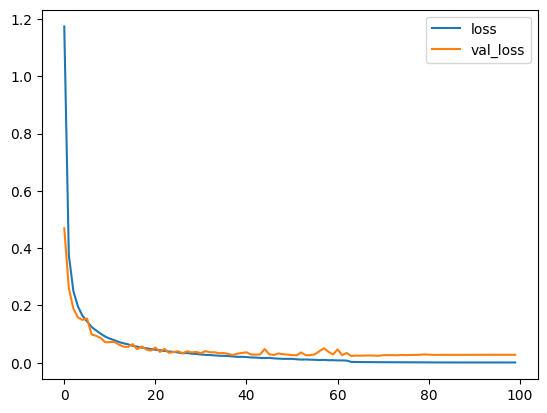

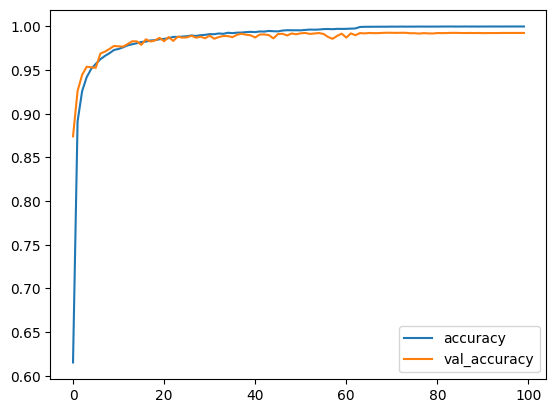

In [10]:
########################################################################################################################
# VIEW TRAINING GRAPHS
########################################################################################################################

plt.clf()
plt.plot(history['loss'], label='loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.savefig(os.path.join(out_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(history['accuracy'], label='accuracy')
plt.plot(history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.savefig(os.path.join(out_folder, 'training_accuracy.png'))
plt.show()

[0.024364288935450326, 0.9928]
Pronađeno je ukupno 72 pogrešno klasifikovanih slika.


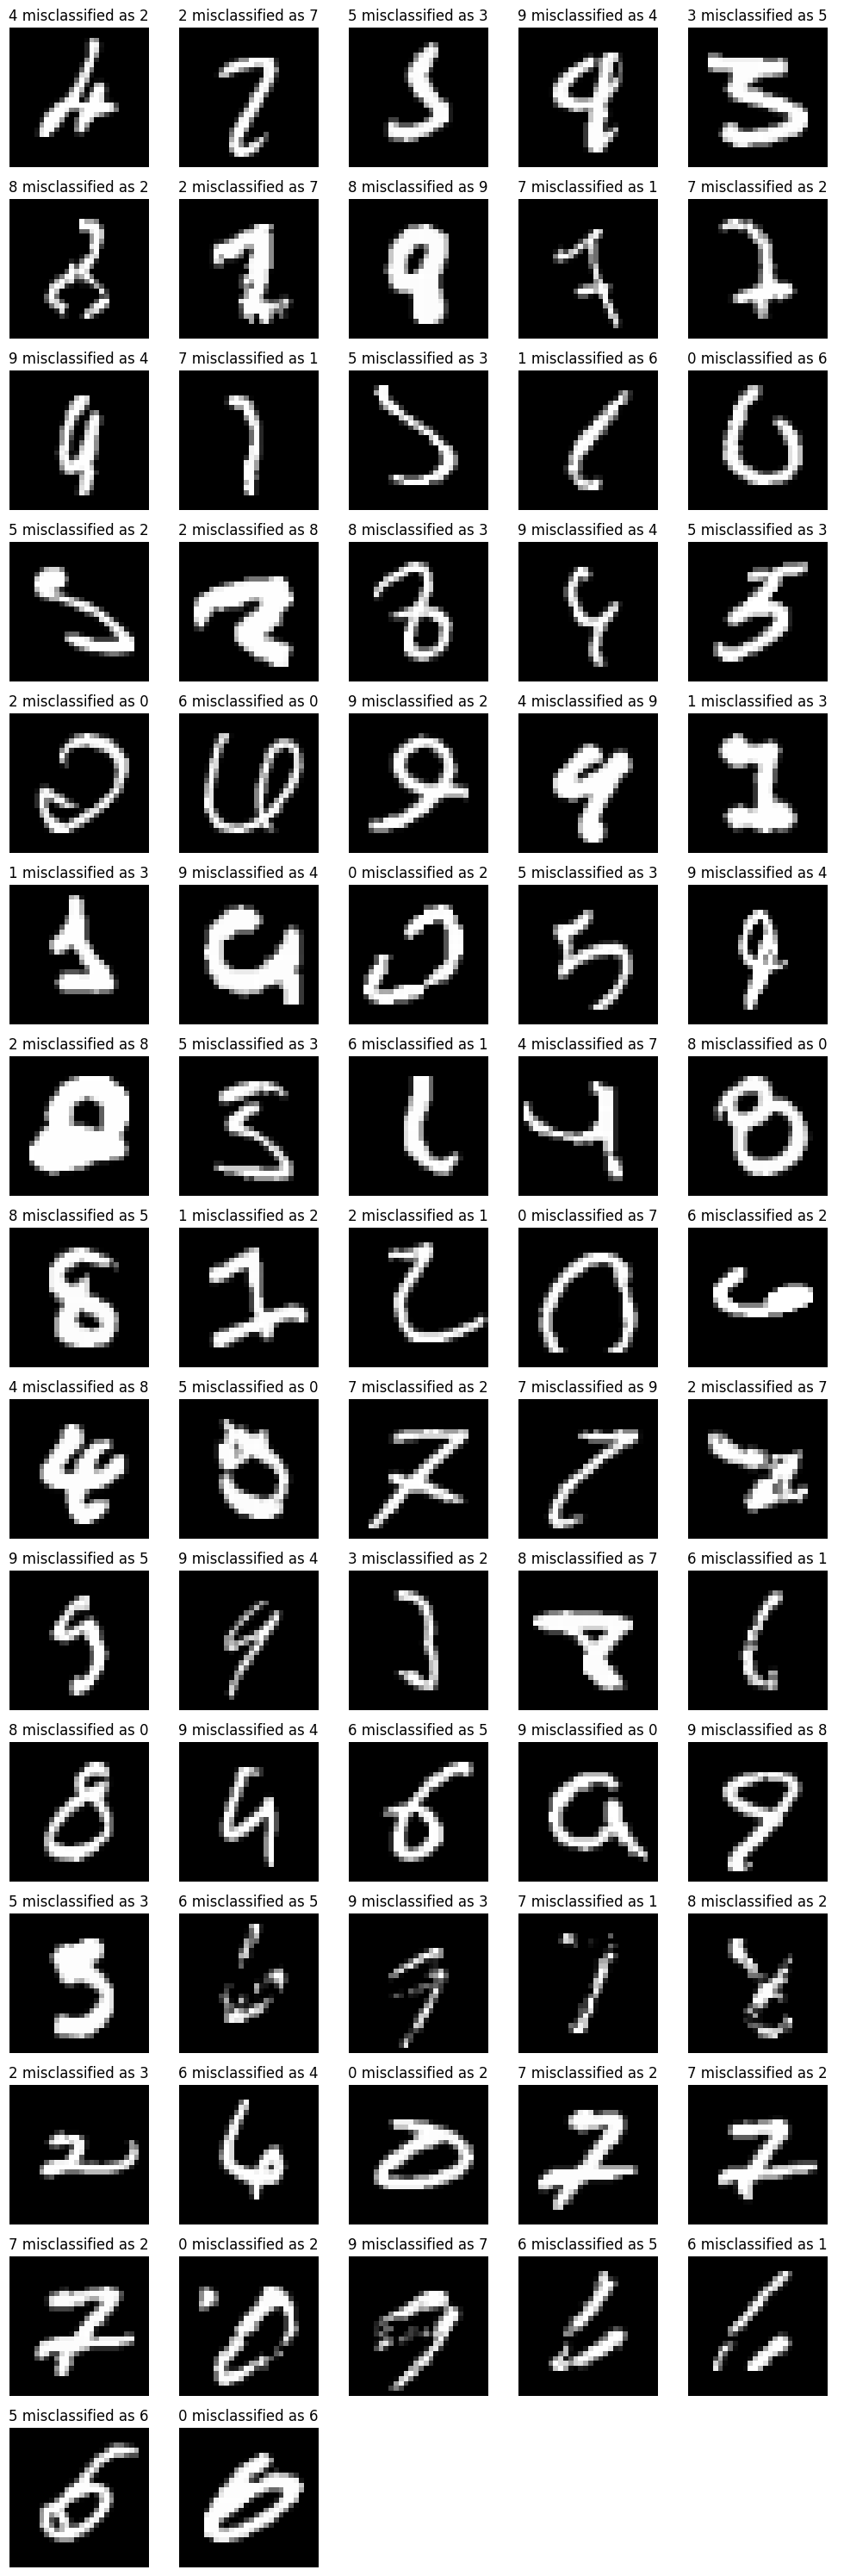

In [11]:
########################################################################################################################
# EVALUATE MODEL
########################################################################################################################

model.eval()

test_loss = 0.0
correct = 0
all_preds = []
num_test = x_test.shape[0]
batch_size = 32

# Evaluacija i prikupljanje svih predviđanja (Ekvivalent za evaluate i predict)
with torch.no_grad():
    for i in range(0, num_test, batch_size):
        images = x_test[i : i + batch_size]
        labels = y_test[i : i + batch_size]

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        # Skupljamo predviđanja (prebacujemo ih na CPU i u NumPy)
        all_preds.extend(predicted.cpu().numpy())

final_loss = test_loss / num_test
final_acc = correct / num_test
print(f"[{final_loss}, {final_acc}]")

# Priprema za analizu grešaka
y_out = np.array(all_preds)
y_test_np = y_test.cpu().numpy() # Osiguravamo da su labele u istom NumPy formatu

# Pronalaženje svih indeksa gde je model pogrešio
error_indices = np.where(y_out != y_test_np)[0]
total_errors = len(error_indices)

print(f"Pronađeno je ukupno {total_errors} pogrešno klasifikovanih slika.")

if total_errors > 0:
    # Dinamičko određivanje dimenzija grida
    cols = 5  # Fiksiramo broj kolona radi preglednosti
    rows = math.ceil(total_errors / cols)  # Zaokruživanje na gore za broj redova

    # Visinu figure (figsize) takođe pravimo dinamičkom kako se slike ne bi sabile
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))

    # Sigurnosna provera: Ako imamo samo 1 red, axes može biti 1D niz.
    # flatten() bezbedno ravna sve u 1D za iteraciju.
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes] # Slučaj kada imamo samo 1 polje ukupno (1x1)

    # Iteracija samo kroz indekse sa greškama
    for i, idx in enumerate(error_indices):
        # Preuzimamo sliku, prebacujemo je na CPU i uklanjamo PyTorch kanalnu dimenziju (1, 28, 28) -> (28, 28)
        img = x_test[idx].cpu().squeeze().numpy()
        out = y_out[idx]
        exp = y_test_np[idx]

        title = f'{exp} misclassified as {out}'

        # Čuvanje slike u folder (na disku)
        file_path = os.path.join(out_folder, f'{i+1} ({title}).png')
        plt.imsave(file_path, img, cmap='gray')

        # Popunjavanje grida
        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    # Uklanjanje viška praznih osa (ako ukupan broj grešaka nije deljiv sa 5)
    for j in range(total_errors, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Model je savršeno klasifikovao sve slike (0 grešaka).")